In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [6]:
df = pd.read_csv("Data\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
pd.set_option('display.max_columns', None) # To stop pandas from truncating the columns.
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [7]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

<Axes: >

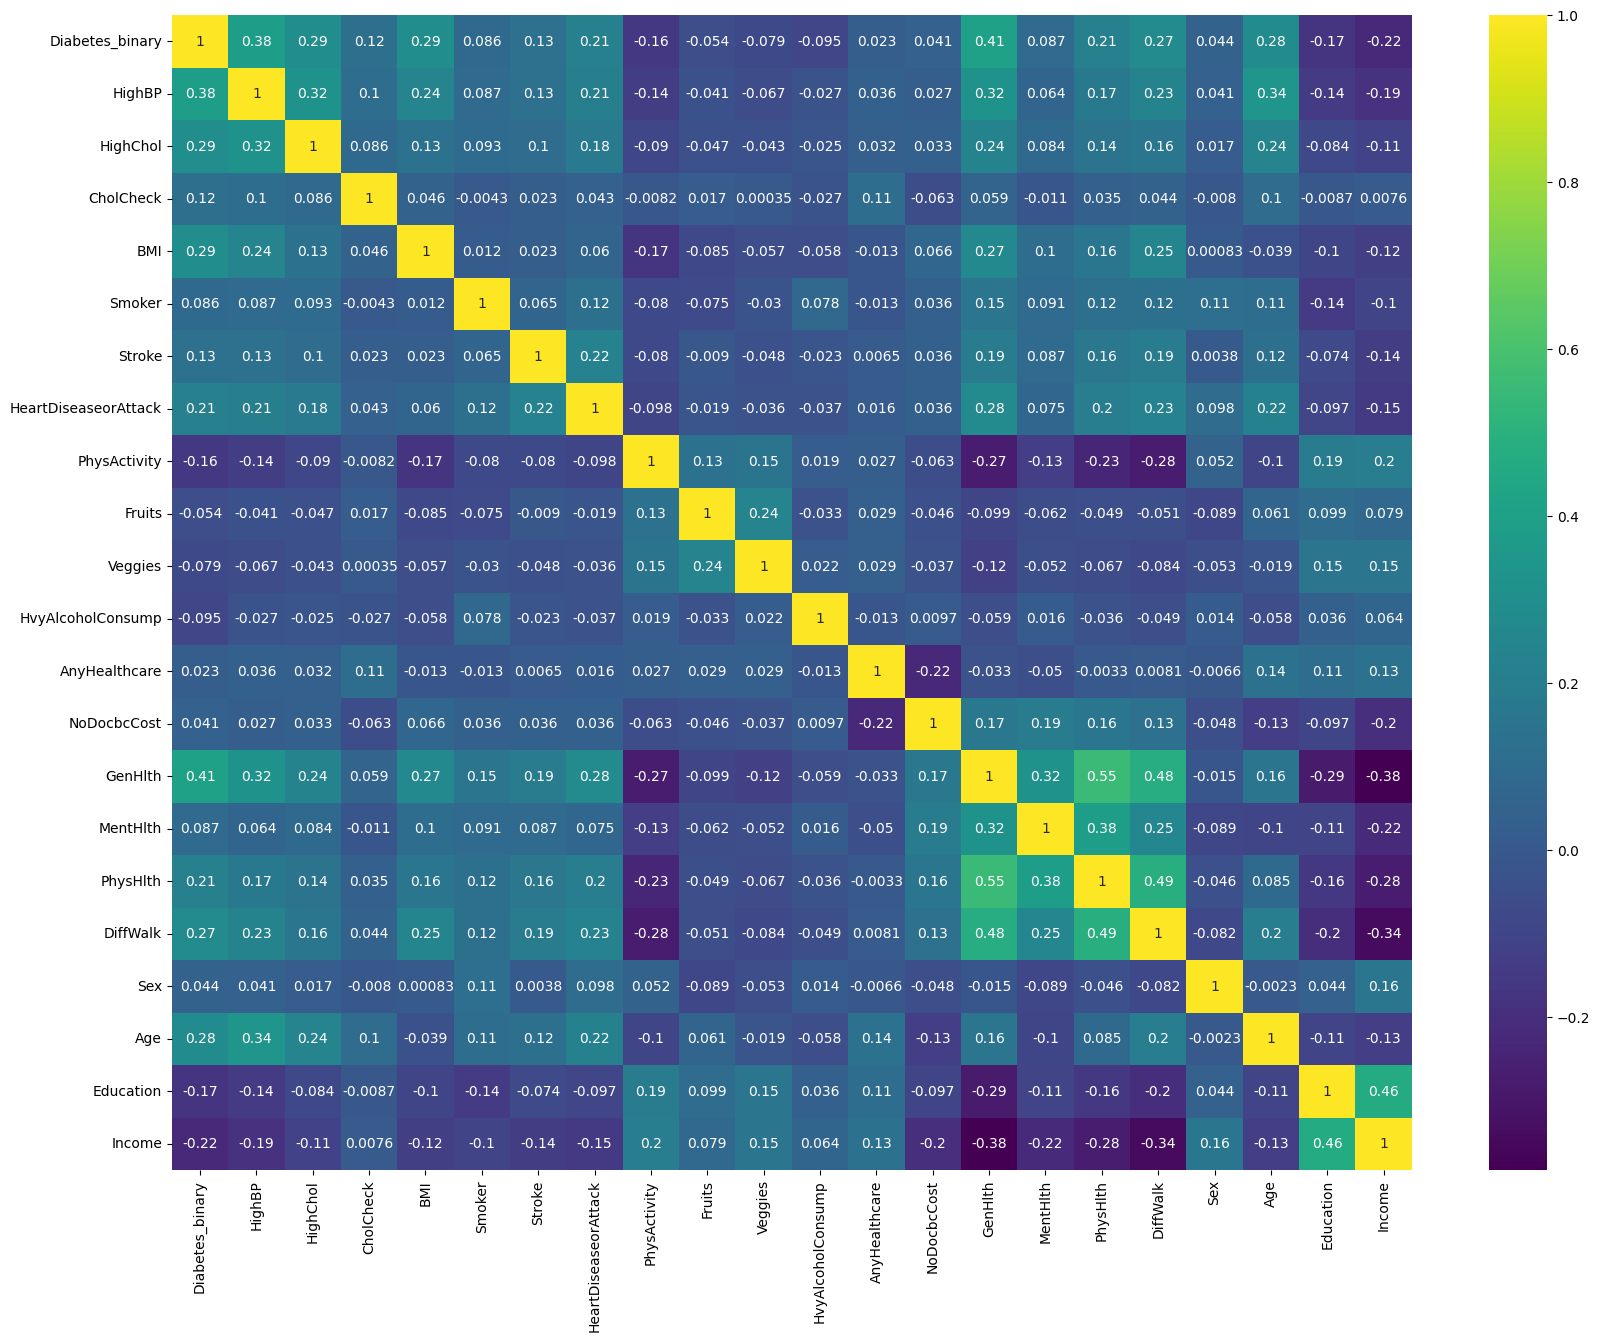

In [14]:
# Making a heatmap to show how features are correlated.
correlation_matrix = df.corr()
fig, ax = plt.subplots(figsize = (20, 15))
sns.heatmap(correlation_matrix, cmap = "viridis", annot=True)

In [ ]:
df.drop(["GenHealth", "DiffWalk"], inplace=True) # These are highly correlated with Physical Health, and thus arent of much use


In [ ]:
# Now we will try to find out if our data is linearly seperable

linear_svc = SVC(kernel='linear') # Passing a linear kernel to test accuracy with it
scaler = StandardScaler()
pipeline = Pipeline([
    ("preprocessing", scaler),
    ("SVMClassifier", linear_svc)
])
pipeline

Pipeline(steps=[('preprocessing', StandardScaler()),
                ('SVMClassifier', SVC(kernel='linear'))])

In [26]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [32]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
bound = int(len(df)*0.8)
X_train, X_test = X[:bound], X[bound:]
y_train, y_test = y[:bound], y[bound:]


In [34]:
pipeline.fit(X_train, y_train) # Fitting the data 

Pipeline(steps=[('preprocessing', StandardScaler()),
                ('SVMClassifier', SVC(kernel='linear'))])

In [35]:
pred = pipeline.predict(X_test)
score = accuracy_score(y_test, pred)
score

0.6521677629252423

In [51]:

final_pipeline = Pipeline([
    ("preprocessing", StandardScaler()),
    ("SVMClassifier", SVC())
])
final_pipeline

Pipeline(steps=[('preprocessing', StandardScaler()), ('SVMClassifier', SVC())])

In [54]:
# Since the score is low, it is not linearly seperable.
# We will try all the remaining kernels to see which will give us the best performance.

param_grid = [{
    "SVMClassifier__kernel": ["poly", 'rbf', 'sigmoid']
}]

search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring="accuracy", cv=5)

In [55]:
search.fit(X_train, y_train)
search.best_params_, search.best_score_

({'SVMClassifier__kernel': 'rbf'}, 0.7475464390313226)